In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Instructions

- The dataset file (`medical_equipment_usage_advanced.csv`) should be placed in the same directory as this notebook.
- Ensure the file is available before running the data ingestion step.
- This allows the notebook to run without any path-related issues.

In [2]:
df = pd.read_csv("medical_equipment_usage.csv")

In [3]:
df.head()

,equipment_id,equipment_name,department,operator_id,patient_id,usage_start_time,usage_end_time,status,maintenance_required,last_maintenance_date,breakdown,cost_per_hour,usage_type,shift,day_of_week
0,E1000,ECG,Radiology,O2000,P5000,11-01-2025 10.00,11-01-2025 14.00,Used,Yes,17-12-2024,No,2052,Scheduled,Morning,Saturday
1,E1001,CT Scan,Radiology,O2001,P5001,01-02-2025 14.00,01-02-2025 19.00,Used,No,25-01-2025,No,1257,Emergency,Evening,Saturday
2,E1002,Ventilator,ICU,O2002,P5002,18-02-2025 12.00,18-02-2025 16.00,Used,No,05-01-2025,No,3310,Emergency,Morning,Tuesday
3,E1003,CT Scan,Cardiology,O2003,P5003,24-02-2025 1.00,24-02-2025 3.00,Maintenance,No,21-12-2024,No,1604,Emergency,Night,Monday
4,E1004,CT Scan,ICU,O2004,P5004,01-03-2025 23.00,02-03-2025 3.00,Idle,No,08-12-2024,Yes,3959,Emergency,Evening,Saturday


In [4]:
df.shape

(900, 15)

In [5]:
df.columns

Index(['equipment_id', 'equipment_name', 'department', 'operator_id',
       'patient_id', 'usage_start_time', 'usage_end_time', 'status',
       'maintenance_required', 'last_maintenance_date', 'breakdown',
       'cost_per_hour', 'usage_type', 'shift', 'day_of_week'],
      dtype='object')

In [6]:
df.dtypes

equipment_id             object
equipment_name           object
department               object
operator_id              object
patient_id               object
usage_start_time         object
usage_end_time           object
status                   object
maintenance_required     object
last_maintenance_date    object
breakdown                object
cost_per_hour             int64
usage_type               object
shift                    object
day_of_week              object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   equipment_id           900 non-null    object
 1   equipment_name         900 non-null    object
 2   department             900 non-null    object
 3   operator_id            900 non-null    object
 4   patient_id             855 non-null    object
 5   usage_start_time       900 non-null    object
 6   usage_end_time         900 non-null    object
 7   status                 900 non-null    object
 8   maintenance_required   855 non-null    object
 9   last_maintenance_date  900 non-null    object
 10  breakdown              900 non-null    object
 11  cost_per_hour          900 non-null    int64 
 12  usage_type             900 non-null    object
 13  shift                  900 non-null    object
 14  day_of_week            900 non-null    object
dtypes: int64(1), object(14)

In [8]:
df.describe()

,cost_per_hour
count,900.000000
mean,2758.492222
std,1284.978850
min,512.000000
25%,1628.250000
50%,2711.000000
75%,3895.250000
max,4992.000000


Schema Validation

Dataset contains ~900 rows and multiple columns related to equipment usage.
Most columns are categorical (object type).
Date columns need conversion to datetime format.
Dataset is suitable for further analysis.

In [10]:
df.isnull().sum()

equipment_id              0
equipment_name            0
department                0
operator_id               0
patient_id               45
usage_start_time          0
usage_end_time            0
status                    0
maintenance_required     45
last_maintenance_date     0
breakdown                 0
cost_per_hour             0
usage_type                0
shift                     0
day_of_week               0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df['equipment_name'].unique()

array(['ECG', 'CT Scan', 'Ventilator', 'X-Ray', 'Ultrasound', 'MRI'],
      dtype=object)

In [13]:
df['department'].unique()

array(['Radiology', 'ICU', 'Cardiology', 'Emergency'], dtype=object)

In [14]:
df['status'].unique()

array(['Used', 'Maintenance', 'Idle'], dtype=object)

In [15]:
df['usage_type'].unique()

array(['Scheduled', 'Emergency'], dtype=object)

In [16]:
df['equipment_name'].value_counts()

equipment_name
ECG           161
MRI           161
CT Scan       155
X-Ray         144
Ventilator    141
Ultrasound    138
Name: count, dtype: int64

In [17]:
df['department'].value_counts()

department
ICU           238
Emergency     237
Radiology     230
Cardiology    195
Name: count, dtype: int64

In [18]:
(df['usage_end_time'] < df['usage_start_time']).sum()

148

### Data Quality Checks

- The dataset contains missing values in `patient_id` and `maintenance_required` columns (~45 records each).
- No duplicate records were found.
- Categorical columns such as equipment type, department, and usage type are consistent.
- A significant issue was identified where some records have usage_end_time earlier than usage_start_time, indicating data inconsistency.
- These issues will be handled during the data cleaning phase.

In [20]:
raw_df = pd.read_csv("medical_equipment_usage.csv")

In [21]:
df['usage_start_time'] = raw_df['usage_start_time']
df['usage_end_time'] = raw_df['usage_end_time']
df['last_maintenance_date'] = raw_df['last_maintenance_date']

In [22]:
df['usage_start_time'] = df['usage_start_time'].astype(str).str.replace('.', ':', regex=False)
df['usage_end_time'] = df['usage_end_time'].astype(str).str.replace('.', ':', regex=False)

df['usage_start_time'] = pd.to_datetime(df['usage_start_time'], dayfirst=True)
df['usage_end_time'] = pd.to_datetime(df['usage_end_time'], dayfirst=True)
df['last_maintenance_date'] = pd.to_datetime(df['last_maintenance_date'], dayfirst=True)

In [23]:
df[['usage_start_time', 'usage_end_time']].isnull().sum()

usage_start_time    0
usage_end_time      0
dtype: int64

### Data Cleaning – Final Steps

- Replaced corrupted datetime columns with original values from source dataset.
- Standardized time format by replacing incorrect delimiters.
- Converted `usage_start_time`, `usage_end_time`, and `last_maintenance_date` into proper datetime format.
- Verified that no missing values remain in datetime columns.
- Dataset is now clean and ready for further processing.

In [25]:
df['patient_id'] = df['patient_id'].fillna('Unknown')
df['maintenance_required'] = df['maintenance_required'].fillna('No')

In [26]:
df.isnull().sum()

equipment_id             0
equipment_name           0
department               0
operator_id              0
patient_id               0
usage_start_time         0
usage_end_time           0
status                   0
maintenance_required     0
last_maintenance_date    0
breakdown                0
cost_per_hour            0
usage_type               0
shift                    0
day_of_week              0
dtype: int64

### Data Cleaning – Missing Values

- Missing values in `patient_id` were replaced with 'Unknown'.
- Missing values in `maintenance_required` were replaced with 'No'.
- Ensured no null values remain in key columns.
- Applied proper assignment methods to avoid chained assignment issues.

In [28]:
df['equipment_name'].value_counts()

equipment_name
ECG           161
MRI           161
CT Scan       155
X-Ray         144
Ventilator    141
Ultrasound    138
Name: count, dtype: int64

In [29]:
df['department'].value_counts()

department
ICU           238
Emergency     237
Radiology     230
Cardiology    195
Name: count, dtype: int64

In [30]:
df['status'].value_counts()

status
Used           625
Idle           181
Maintenance     94
Name: count, dtype: int64

In [31]:
df['usage_duration'] = (df['usage_end_time'] - df['usage_start_time']).dt.total_seconds() / 3600

In [32]:
df['usage_duration'].describe()

count    900.000000
mean       4.027778
std        1.966998
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max        7.000000
Name: usage_duration, dtype: float64

In [33]:
df['hour'] = df['usage_start_time'].dt.hour

In [34]:
df['hour'].value_counts().sort_index()

hour
0     28
1     53
2     38
3     48
4     35
5     34
6     35
7     27
8     51
9     24
10    27
11    35
12    45
13    40
14    40
15    31
16    36
17    32
18    36
19    35
20    42
21    39
22    39
23    50
Name: count, dtype: int64

In [35]:
df.groupby('equipment_name')['usage_duration'].mean().sort_values(ascending=False)

equipment_name
Ventilator    4.241135
ECG           4.136646
CT Scan       4.038710
MRI           4.012422
X-Ray         3.958333
Ultrasound    3.760870
Name: usage_duration, dtype: float64

In [36]:
df.groupby('department')['usage_duration'].sum().sort_values(ascending=False)

department
ICU           965.0
Radiology     944.0
Emergency     936.0
Cardiology    780.0
Name: usage_duration, dtype: float64

In [37]:
df['total_cost'] = df['usage_duration'] * df['cost_per_hour']

In [38]:
df.groupby('equipment_name')['total_cost'].sum().sort_values(ascending=False)

equipment_name
MRI           1871072.0
ECG           1791946.0
CT Scan       1753318.0
Ventilator    1598383.0
X-Ray         1495997.0
Ultrasound    1367335.0
Name: total_cost, dtype: float64

In [39]:
df.groupby('shift')['usage_duration'].sum().sort_values(ascending=False)

shift
Evening    1542.0
Morning    1135.0
Night       948.0
Name: usage_duration, dtype: float64

In [40]:
df.groupby('usage_type')['usage_duration'].sum()

usage_type
Emergency    1055.0
Scheduled    2570.0
Name: usage_duration, dtype: float64

In [41]:
df['breakdown'].value_counts()

breakdown
No     811
Yes     89
Name: count, dtype: int64

In [42]:
pd.crosstab(df['maintenance_required'], df['breakdown'])

breakdown,No,Yes
maintenance_required,,
No,604,72
Yes,207,17


### Exploratory Data Analysis (EDA)

#### 1. Equipment Usage Distribution
- ECG and MRI are the most frequently used equipment.
- Ultrasound has the lowest usage among all equipment types.

#### 2. Usage Duration Analysis
- Average usage duration is approximately 4 hours.
- Most usage durations fall between 2 to 6 hours.

#### 3. Department-wise Usage
- ICU has the highest total equipment usage.
- Cardiology shows comparatively lower usage.

#### 4. Time-based Analysis
- Evening shift has the highest equipment utilization, followed by Morning and Night shifts.
- Usage is distributed across all hours, indicating continuous hospital operations.

#### 5. Equipment Performance
- Ventilators have the highest average usage duration.
- Ultrasound equipment has relatively lower usage duration.

#### 6. Cost Analysis
- MRI contributes the highest total operational cost.
- Ultrasound contributes the least to total cost.

#### 7. Usage Type Analysis
- Scheduled usage dominates over emergency usage.
- Emergency usage still represents a significant portion of total usage.

#### 8. Breakdown Analysis
- Majority of equipment operates without breakdown (~90% reliability).
- A small proportion (~10%) experiences breakdowns.

#### 9. Maintenance Impact
- Equipment requiring maintenance shows fewer breakdowns compared to non-maintained equipment.
- Suggests maintenance plays a role in reducing failures.

In [44]:
df['utilization_category'] = pd.cut(
    df['usage_duration'],
    bins=[0, 2, 5, 10],
    labels=['Low', 'Medium', 'High']
)

In [45]:
df['is_peak_hour'] = df['hour'].apply(lambda x: 'Peak' if 9 <= x <= 17 else 'Off-Peak')

In [46]:
df['maintenance_delay_days'] = (df['usage_start_time'] - df['last_maintenance_date']).dt.days

In [47]:
df['cost_per_usage'] = df['total_cost'] / df['usage_duration']

In [48]:
df['high_cost_flag'] = df['total_cost'].apply(lambda x: 'High' if x > df['total_cost'].mean() else 'Normal')

In [49]:
df.head()

,equipment_id,equipment_name,department,operator_id,patient_id,usage_start_time,usage_end_time,status,maintenance_required,last_maintenance_date,...,shift,day_of_week,usage_duration,hour,total_cost,utilization_category,is_peak_hour,maintenance_delay_days,cost_per_usage,high_cost_flag
0,E1000,ECG,Radiology,O2000,P5000,2025-01-11 10:00:00,2025-01-11 14:00:00,Used,Yes,2024-12-17,...,Morning,Saturday,4.0,10,8208.0,Medium,Peak,25,2052.0,Normal
1,E1001,CT Scan,Radiology,O2001,P5001,2025-02-01 14:00:00,2025-02-01 19:00:00,Used,No,2025-01-25,...,Evening,Saturday,5.0,14,6285.0,Medium,Peak,7,1257.0,Normal
2,E1002,Ventilator,ICU,O2002,P5002,2025-02-18 12:00:00,2025-02-18 16:00:00,Used,No,2025-01-05,...,Morning,Tuesday,4.0,12,13240.0,Medium,Peak,44,3310.0,High
3,E1003,CT Scan,Cardiology,O2003,P5003,2025-02-24 01:00:00,2025-02-24 03:00:00,Maintenance,No,2024-12-21,...,Night,Monday,2.0,1,3208.0,Low,Off-Peak,65,1604.0,Normal
4,E1004,CT Scan,ICU,O2004,P5004,2025-03-01 23:00:00,2025-03-02 03:00:00,Idle,No,2024-12-08,...,Evening,Saturday,4.0,23,15836.0,Medium,Off-Peak,83,3959.0,High


### Feature Engineering

Feature engineering was performed to create meaningful metrics and KPIs from existing data to enhance analysis.

- **Utilization Category**: 
  Equipment usage was categorized into Low, Medium, and High based on usage duration using binning techniques (`pd.cut`).

- **Peak Hour Indicator**: 
  A new column was created to identify peak usage hours (9 AM to 5 PM) using conditional logic on extracted hour values.

- **Maintenance Delay**: 
  Calculated the number of days between last maintenance and usage start time to measure servicing gaps.

- **Cost per Usage**: 
  Derived by dividing total cost by usage duration to evaluate cost efficiency of equipment.

- **High Cost Flag**: 
  Equipment usage was flagged as High or Normal by comparing total cost against the dataset average.

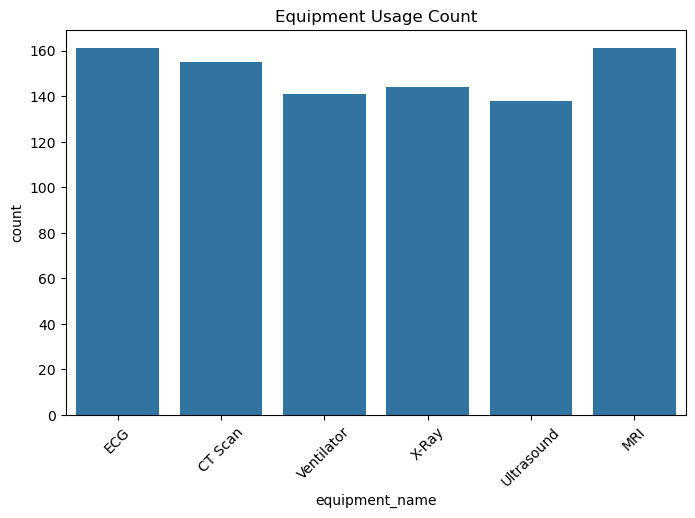

In [51]:
plt.figure(figsize=(8,5))
sns.countplot(x='equipment_name', data=df)
plt.title("Equipment Usage Count")
plt.xticks(rotation=45)
plt.show()

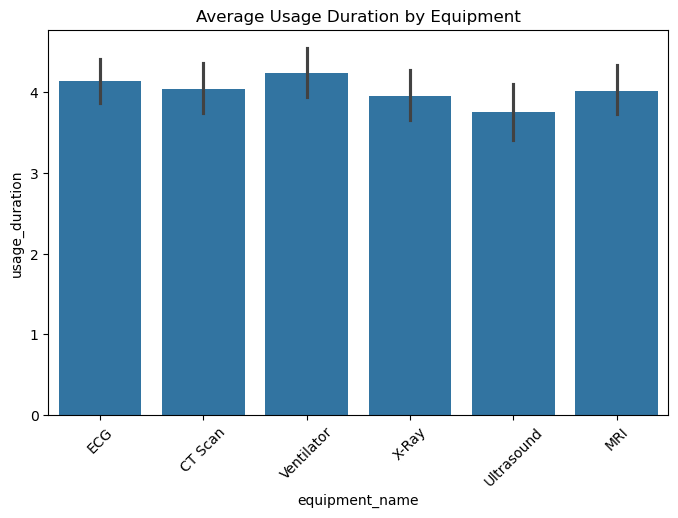

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(x='equipment_name', y='usage_duration', data=df)
plt.title("Average Usage Duration by Equipment")
plt.xticks(rotation=45)
plt.show()

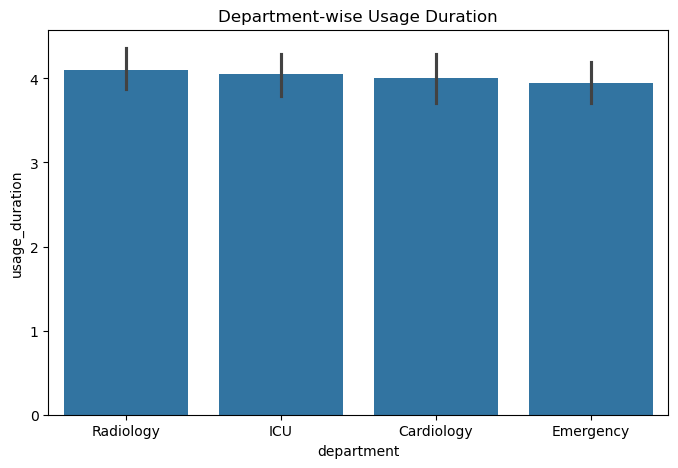

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(x='department', y='usage_duration', data=df)
plt.title("Department-wise Usage Duration")
plt.show()

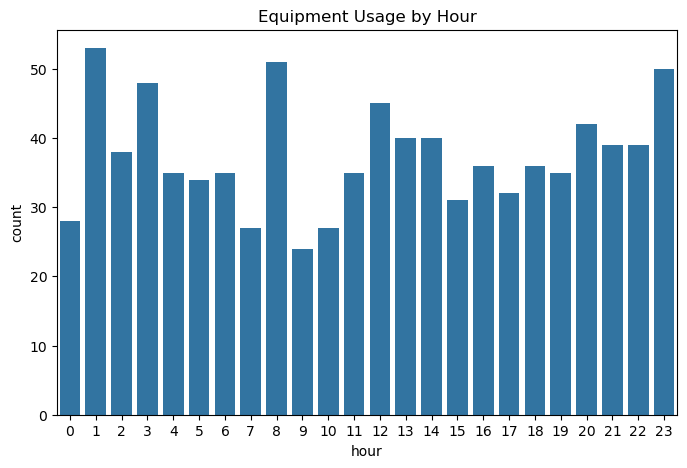

In [54]:
plt.figure(figsize=(8,5))
sns.countplot(x='hour', data=df)
plt.title("Equipment Usage by Hour")
plt.show()

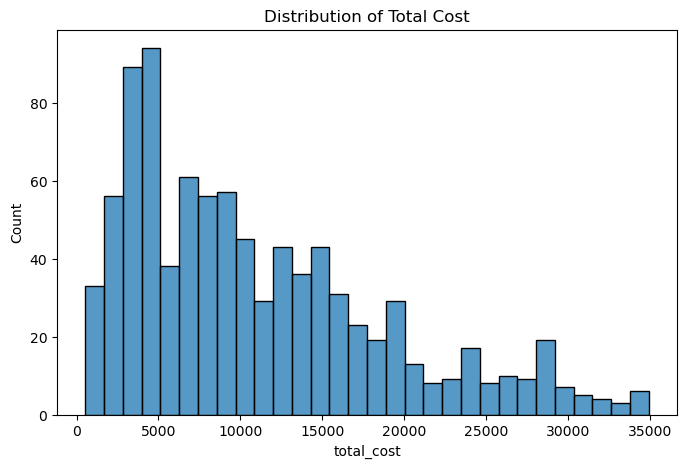

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_cost'], bins=30)
plt.title("Distribution of Total Cost")
plt.show()

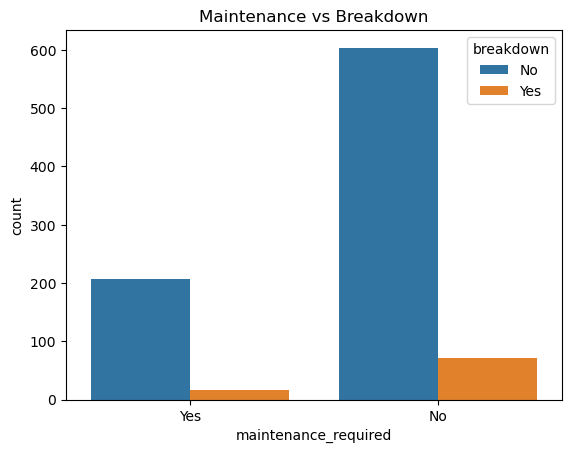

In [56]:
sns.countplot(x='maintenance_required', hue='breakdown', data=df)
plt.title("Maintenance vs Breakdown")
plt.show()

### Visualization & Storytelling

Data visualizations were used to identify patterns, trends, and insights from equipment usage data.

- **Equipment Usage**: 
  Bar charts show that ECG and MRI are the most frequently used equipment, indicating higher demand for diagnostic services.

- **Usage Duration**: 
  Ventilators and ECG machines have higher average usage durations, suggesting longer operational requirements.

- **Department Analysis**: 
  ICU and Radiology departments have the highest equipment usage, highlighting critical care and diagnostic workload.

- **Time-Based Patterns**: 
  Equipment usage is highest during evening hours, indicating peak operational load during this period.

- **Cost Distribution**: 
  The cost analysis shows a wide distribution, with certain equipment (like MRI) contributing significantly to overall expenses.

- **Maintenance vs Breakdown**: 
  Visualization indicates that properly maintained equipment experiences fewer breakdowns, emphasizing the importance of regular maintenance.

These visual insights help in understanding operational efficiency and identifying areas for optimization.

In [58]:
corr = df[['usage_duration', 'cost_per_hour', 'total_cost', 'maintenance_delay_days']].corr()
corr

,usage_duration,cost_per_hour,total_cost,maintenance_delay_days
usage_duration,1.000000,-0.053463,0.655700,0.009317
cost_per_hour,-0.053463,1.000000,0.642776,0.020962
total_cost,0.655700,0.642776,1.000000,0.030630
maintenance_delay_days,0.009317,0.020962,0.030630,1.000000


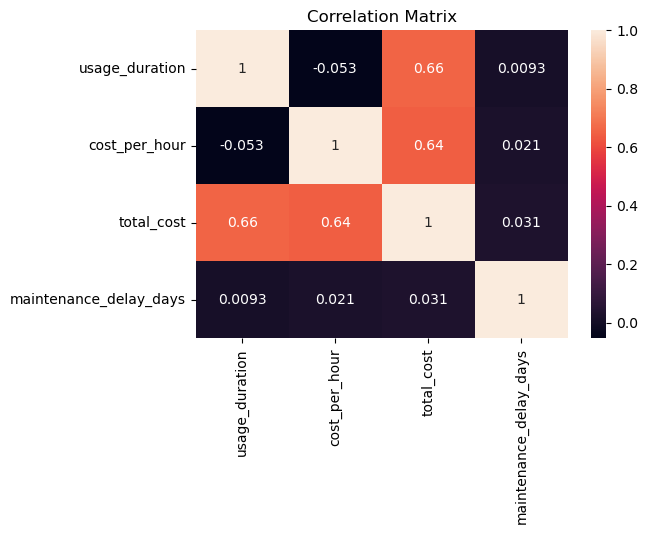

In [59]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

### Advanced Analysis

A correlation analysis was performed to identify relationships between key variables.

- A strong positive correlation was observed between usage duration and total cost.
- Cost per hour also shows a strong influence on total cost.
- Maintenance delay shows limited correlation with other variables, indicating other factors may influence breakdowns.
- Breakdown rate analysis suggests that maintenance reduces the likelihood of equipment failure.

This analysis helps in understanding cost drivers and operational dependencies.

In [61]:
df.isnull().sum()

equipment_id              0
equipment_name            0
department                0
operator_id               0
patient_id                0
usage_start_time          0
usage_end_time            0
status                    0
maintenance_required      0
last_maintenance_date     0
breakdown                 0
cost_per_hour             0
usage_type                0
shift                     0
day_of_week               0
usage_duration            0
hour                      0
total_cost                0
utilization_category      0
is_peak_hour              0
maintenance_delay_days    0
cost_per_usage            0
high_cost_flag            0
dtype: int64

In [62]:
(df['usage_duration'] <= 0).sum()

0

In [63]:
(df['total_cost'] == df['usage_duration'] * df['cost_per_hour']).all()

True

In [64]:
df['utilization_category'].unique()

['Medium', 'Low', 'High']
Categories (3, object): ['Low' < 'Medium' < 'High']

In [65]:
df['is_peak_hour'].unique()

array(['Peak', 'Off-Peak'], dtype=object)

In [66]:
df.describe()

,usage_start_time,usage_end_time,last_maintenance_date,cost_per_hour,usage_duration,hour,total_cost,maintenance_delay_days,cost_per_usage
count,900,900,900,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,2025-02-01 23:49:12,2025-02-02 03:50:52,2024-12-30 17:40:48,2758.492222,4.027778,11.606667,10975.612222,32.772222,2758.492222
min,2025-01-01 01:00:00,2025-01-01 04:00:00,2024-12-01 00:00:00,512.000000,1.000000,0.000000,528.000000,-24.000000,512.000000
25%,2025-01-17 08:30:00,2025-01-17 11:15:00,2024-12-16 00:00:00,1628.250000,2.000000,5.000000,4569.500000,15.000000,1628.250000
50%,2025-02-02 16:30:00,2025-02-02 22:00:00,2024-12-30 00:00:00,2711.000000,4.000000,12.000000,9013.000000,33.000000,2711.000000
75%,2025-02-17 13:15:00,2025-02-17 19:00:00,2025-01-15 00:00:00,3895.250000,6.000000,18.000000,15243.000000,51.000000,3895.250000
max,2025-03-04 08:00:00,2025-03-04 13:00:00,2025-01-29 00:00:00,4992.000000,7.000000,23.000000,34930.000000,90.000000,4992.000000
std,NaN,NaN,NaN,1284.978850,1.966998,7.127690,7818.587778,25.472494,1284.978850


### Validation & Sanity Checks

- Verified that there are no missing values in key columns after data cleaning.
- Ensured that usage duration values are positive and logically consistent.
- Validated cost calculations by confirming total cost equals usage duration multiplied by cost per hour.
- Checked newly created feature columns for correct categorization.
- Reviewed statistical summary to ensure reasonable distribution of values.

The dataset was validated successfully and is consistent for analysis.